## Load in packages and data

In [1]:
import numpy as np
import pandas as pd
# import geopandas as gpd
import matplotlib.pyplot as plt
import matsim_output_analysis_experienced_te as moa
import operator

In [19]:

df_pl = pd.read_csv(r"2705_2040_0.1pc_keep20.csv") #this is the 2040 do minimum plans
df_ex = pd.read_csv(r"2705_2040_0.1pc_keep20_experienced.csv") #this is the 2040 do minimum plans


df_ex = df_ex[["id", "selected plan activity_type_or_mode", "selected plan utility", "selected plan duration", "selected plan distance_travelled", "selected plan routes", "selected plan boardingTime", "selected plan location"]]
df_ex.columns = ["id" , "experienced plan activity_type_or_mode", "experienced plan utility", "experienced plan duration", "experienced plan distance_travelled", "experienced plan routes", "experienced plan boardingTime", "experienced plan location"]


In [20]:
df = pd.merge(df_pl, df_ex, how = "outer", on="id")

In [21]:
# #the following is only needed for handling experienced plans
df["stuck_bool"] =  (df["selected plan activity_type_or_mode"] != df["experienced plan activity_type_or_mode"]).astype(int) #so the bool tells us: 1 if stuck, 0 if not stuck
df = df[df["stuck_bool"]==0] # just for now. need to have unselected experienced too fo rbetter handling

In [22]:
df = df[~df["subpopulation"].isin(["hgv","lgv","airport", "lgv_ev"])] 
df = df[~df["id"].isin(["empty_plan"])] #choose only the actual people

In [23]:
diffs1 = df[df["selected plan utility"]!= df["unselected plan (1) utility"]]
print(f"there are {len(diffs1)} agents with varying utility; {(len(diffs1)/(len(df)) * 100)}% of the population")

there are 4108 agents with varying utility; 93.36363636363636% of the population


In [24]:
diffs2 = df[df["selected plan activity_type_or_mode"]!= df["unselected plan (1) activity_type_or_mode"]]
print(f"there are {len(diffs2)} agents with varying plans; {(len(diffs2)/(len(df)) * 100)}% of the population")

there are 657 agents with varying plans; 14.931818181818182% of the population


In [25]:
# check for agents who do not complete their planned plan in their selected plan
df["stuck_selected"] =  (df["selected plan activity_type_or_mode"] != df["experienced plan activity_type_or_mode"]).astype(int) #so the bool tells us: 1 if stuck, 0 if not stuck

#check for agents who do not complete their planned plan in their unselected plan
df["stuck_unselected"] = (df["selected plan activity_type_or_mode"] != df["unselected plan (1) activity_type_or_mode"]).astype(int) #so the bool tells us: 1 if stuck, 0 if not stuck

In [26]:
#turn plan summaries into lists instead of long strings
df['selected plan activity_type_or_mode'] = df['selected plan activity_type_or_mode'].str.split('; ')
df['selected plan distance_travelled'] = df['selected plan distance_travelled'].str.split('; ')
df['selected plan duration'] = df['selected plan duration'].str.split('; ')
df['selected plan location'] = df['selected plan location'].str.split('; ')
df['selected plan routes'] = df['selected plan routes'].str.split('; ')
df['selected plan boardingTime'] = df['selected plan boardingTime'].str.split('; ')

In [27]:
df['experienced plan activity_type_or_mode'] = df['experienced plan activity_type_or_mode'].str.split('; ')
df['experienced plan distance_travelled'] = df['experienced plan distance_travelled'].str.split('; ')
df['experienced plan duration'] = df['experienced plan duration'].str.split('; ')
df['experienced plan location'] = df['experienced plan location'].str.split('; ')
df['experienced plan routes'] = df['experienced plan routes'].str.split('; ')
df['experienced plan boardingTime'] = df['experienced plan boardingTime'].str.split('; ')

In [28]:
df['unselected plan (1) activity_type_or_mode'] = df['unselected plan (1) activity_type_or_mode'].str.split('; ')
df['unselected plan (1) distance_travelled'] = df['unselected plan (1) distance_travelled'].str.split('; ')
df['unselected plan (1) duration'] = df['unselected plan (1) duration'].str.split('; ')
df['unselected plan (1) location'] = df['unselected plan (1) location'].str.split('; ')
df['unselected plan (1) routes'] = df['unselected plan (1) routes'].str.split('; ')
df['unselected plan (1) boardingTime'] = df['unselected plan (1) boardingTime'].str.split('; ')

In [29]:
df['unselected plan (2) activity_type_or_mode'] = df['unselected plan (2) activity_type_or_mode'].str.split('; ')
df['unselected plan (2) distance_travelled'] = df['unselected plan (2) distance_travelled'].str.split('; ')
df['unselected plan (2) duration'] = df['unselected plan (2) duration'].str.split('; ')
df['unselected plan (2) location'] = df['unselected plan (2) location'].str.split('; ')
df['unselected plan (2) routes'] = df['unselected plan (2) routes'].str.split('; ')
df['unselected plan (2) boardingTime'] = df['unselected plan (2) boardingTime'].str.split('; ')

In [30]:
df['unselected plan (3) activity_type_or_mode'] = df['unselected plan (3) activity_type_or_mode'].str.split('; ')
df['unselected plan (3) distance_travelled'] = df['unselected plan (3) distance_travelled'].str.split('; ')
df['unselected plan (3) duration'] = df['unselected plan (3) duration'].str.split('; ')
df['unselected plan (3) location'] = df['unselected plan (3) location'].str.split('; ')
df['unselected plan (3) routes'] = df['unselected plan (3) routes'].str.split('; ')
df['unselected plan (3) boardingTime'] = df['unselected plan (3) boardingTime'].str.split('; ')

In [31]:
df['unselected plan (4) activity_type_or_mode'] = df['unselected plan (4) activity_type_or_mode'].str.split('; ')
df['unselected plan (4) distance_travelled'] = df['unselected plan (4) distance_travelled'].str.split('; ')
df['unselected plan (4) duration'] = df['unselected plan (4) duration'].str.split('; ')
df['unselected plan (4) location'] = df['unselected plan (4) location'].str.split('; ')
df['unselected plan (4) routes'] = df['unselected plan (4) routes'].str.split('; ')
df['unselected plan (4) boardingTime'] = df['unselected plan (4) boardingTime'].str.split('; ')

## Remove "pt interaction" terms and all corresponding columns

In [32]:
#extract the indices of where pt interaction happens
df['selected plan ptinteraction_indices'] = df['selected plan activity_type_or_mode'].apply(moa.get_ptinteraction_index)
df['experienced plan ptinteraction_indices'] = df['experienced plan activity_type_or_mode'].apply(moa.get_ptinteraction_index)
df['unselected plan (1) ptinteraction_indices'] = df['unselected plan (1) activity_type_or_mode'].apply(moa.get_ptinteraction_index)
df['unselected plan (2) ptinteraction_indices'] = df['unselected plan (2) activity_type_or_mode'].apply(moa.get_ptinteraction_index)
df['unselected plan (3) ptinteraction_indices'] = df['unselected plan (3) activity_type_or_mode'].apply(moa.get_ptinteraction_index)
df['unselected plan (4) ptinteraction_indices'] = df['unselected plan (4) activity_type_or_mode'].apply(moa.get_ptinteraction_index)

In [33]:
#remove the pt interaction activities
df['selected plan activity_type_or_mode'] = df.apply(lambda row: moa.remove_ptinteraction(row['selected plan ptinteraction_indices'], row['selected plan activity_type_or_mode']), axis=1)
df['experienced plan activity_type_or_mode'] = df.apply(lambda row: moa.remove_ptinteraction(row['experienced plan ptinteraction_indices'], row['experienced plan activity_type_or_mode']), axis=1)
df['unselected plan (1) activity_type_or_mode'] = df.apply(lambda row: moa.remove_ptinteraction(row['unselected plan (1) ptinteraction_indices'], row['unselected plan (1) activity_type_or_mode']), axis=1)
df['unselected plan (2) activity_type_or_mode'] = df.apply(lambda row: moa.remove_ptinteraction(row['unselected plan (2) ptinteraction_indices'], row['unselected plan (2) activity_type_or_mode']), axis=1)
df['unselected plan (3) activity_type_or_mode'] = df.apply(lambda row: moa.remove_ptinteraction(row['unselected plan (3) ptinteraction_indices'], row['unselected plan (3) activity_type_or_mode']), axis=1)
df['unselected plan (4) activity_type_or_mode'] = df.apply(lambda row: moa.remove_ptinteraction(row['unselected plan (4) ptinteraction_indices'], row['unselected plan (4) activity_type_or_mode']), axis=1)

In [34]:
#remove the correspinding pt interaction durations
df['selected plan duration'] = df.apply(lambda row: moa.remove_ptinteraction(row['selected plan ptinteraction_indices'], row['selected plan duration']), axis=1)
df['experienced plan duration'] = df.apply(lambda row: moa.remove_ptinteraction(row['experienced plan ptinteraction_indices'], row['experienced plan duration']), axis=1)
df['unselected plan (1) duration'] = df.apply(lambda row: moa.remove_ptinteraction(row['unselected plan (1) ptinteraction_indices'], row['unselected plan (1) duration']), axis=1)
df['unselected plan (2) duration'] = df.apply(lambda row: moa.remove_ptinteraction(row['unselected plan (2) ptinteraction_indices'], row['unselected plan (2) duration']), axis=1)
df['unselected plan (3) duration'] = df.apply(lambda row: moa.remove_ptinteraction(row['unselected plan (3) ptinteraction_indices'], row['unselected plan (3) duration']), axis=1)
df['unselected plan (4) duration'] = df.apply(lambda row: moa.remove_ptinteraction(row['unselected plan (4) ptinteraction_indices'], row['unselected plan (4) duration']), axis=1)

In [35]:
#remove the correspinding pt interaction locations
df['selected plan location'] = df.apply(lambda row: moa.remove_ptinteraction(row['selected plan ptinteraction_indices'], row['selected plan location']), axis=1)
df['experienced plan location'] = df.apply(lambda row: moa.remove_ptinteraction(row['experienced plan ptinteraction_indices'], row['experienced plan location']), axis=1)
df['unselected plan (1) location'] = df.apply(lambda row: moa.remove_ptinteraction(row['unselected plan (1) ptinteraction_indices'], row['unselected plan (1) location']), axis=1)
df['unselected plan (2) location'] = df.apply(lambda row: moa.remove_ptinteraction(row['unselected plan (2) ptinteraction_indices'], row['unselected plan (2) location']), axis=1)
df['unselected plan (3) location'] = df.apply(lambda row: moa.remove_ptinteraction(row['unselected plan (3) ptinteraction_indices'], row['unselected plan (3) location']), axis=1)
df['unselected plan (4) location'] = df.apply(lambda row: moa.remove_ptinteraction(row['unselected plan (4) ptinteraction_indices'], row['unselected plan (4) location']), axis=1)

In [36]:
#remove the correspinding pt interaction distance travelled
df['selected plan distance_travelled'] = df.apply(lambda row: moa.remove_ptinteraction(row['selected plan ptinteraction_indices'], row['selected plan distance_travelled']), axis=1)
df['experienced plan distance_travelled'] = df.apply(lambda row: moa.remove_ptinteraction(row['experienced plan ptinteraction_indices'], row['experienced plan distance_travelled']), axis=1)
df['unselected plan (1) distance_travelled'] = df.apply(lambda row: moa.remove_ptinteraction(row['unselected plan (1) ptinteraction_indices'], row['unselected plan (1) distance_travelled']), axis=1)
df['unselected plan (2) distance_travelled'] = df.apply(lambda row: moa.remove_ptinteraction(row['unselected plan (2) ptinteraction_indices'], row['unselected plan (2) distance_travelled']), axis=1)
df['unselected plan (3) distance_travelled'] = df.apply(lambda row: moa.remove_ptinteraction(row['unselected plan (3) ptinteraction_indices'], row['unselected plan (3) distance_travelled']), axis=1)
df['unselected plan (4) distance_travelled'] = df.apply(lambda row: moa.remove_ptinteraction(row['unselected plan (4) ptinteraction_indices'], row['unselected plan (4) distance_travelled']), axis=1)

In [37]:
#remove the correspinding pt interaction distance travelled
df['selected plan boardingTime'] = df.apply(lambda row: moa.remove_ptinteraction(row['selected plan ptinteraction_indices'], row['selected plan boardingTime']), axis=1)
df['experienced plan boardingTime'] = df.apply(lambda row: moa.remove_ptinteraction(row['experienced plan ptinteraction_indices'], row['experienced plan boardingTime']), axis=1)
df['unselected plan (1) boardingTime'] = df.apply(lambda row: moa.remove_ptinteraction(row['unselected plan (1) ptinteraction_indices'], row['unselected plan (1) boardingTime']), axis=1)
df['unselected plan (2) boardingTime'] = df.apply(lambda row: moa.remove_ptinteraction(row['unselected plan (2) ptinteraction_indices'], row['unselected plan (2) boardingTime']), axis=1)
df['unselected plan (3) boardingTime'] = df.apply(lambda row: moa.remove_ptinteraction(row['unselected plan (3) ptinteraction_indices'], row['unselected plan (3) boardingTime']), axis=1)
df['unselected plan (4) boardingTime'] = df.apply(lambda row: moa.remove_ptinteraction(row['unselected plan (4) ptinteraction_indices'], row['unselected plan (4) boardingTime']), axis=1)

In [38]:
#remove the correspinding pt interaction distance travelled
df['selected plan routes'] = df.apply(lambda row: moa.remove_ptinteraction(row['selected plan ptinteraction_indices'], row['selected plan routes']), axis=1)
df['experienced plan routes'] = df.apply(lambda row: moa.remove_ptinteraction(row['experienced plan ptinteraction_indices'], row['experienced plan routes']), axis=1)
df['unselected plan (1) routes'] = df.apply(lambda row: moa.remove_ptinteraction(row['unselected plan (1) ptinteraction_indices'], row['unselected plan (1) routes']), axis=1)
df['unselected plan (2) routes'] = df.apply(lambda row: moa.remove_ptinteraction(row['unselected plan (2) ptinteraction_indices'], row['unselected plan (2) routes']), axis=1)
df['unselected plan (3) routes'] = df.apply(lambda row: moa.remove_ptinteraction(row['unselected plan (3) ptinteraction_indices'], row['unselected plan (3) routes']), axis=1)
df['unselected plan (4) routes'] = df.apply(lambda row: moa.remove_ptinteraction(row['unselected plan (4) ptinteraction_indices'], row['unselected plan (4) routes']), axis=1)

In [39]:
#clean  up table and remove indices
df = df.drop(["selected plan ptinteraction_indices","unselected plan (1) ptinteraction_indices", "experienced plan ptinteraction_indices","unselected plan (2) ptinteraction_indices","unselected plan (3) ptinteraction_indices","unselected plan (4) ptinteraction_indices"], axis=1)

## Calculating utility components

Get activity start and end times, and highlight any "stuck" agents

In [40]:
df["sp_legs_indices"] = df["selected plan activity_type_or_mode"].apply(moa.get_trips_indices_only)
df["sp_activities_indices"] = df["selected plan activity_type_or_mode"].apply(moa.get_activities_indices_only)
df["sp_leg_durations"] = df.apply(lambda row: moa.get_trips_duration_or_mode(row["sp_legs_indices"], row["selected plan duration"]), axis=1)
df["sp_activity_durations"] = df.apply(lambda row: moa.get_trips_duration_or_mode(row["sp_activities_indices"], row["selected plan duration"]), axis=1)


In [41]:
df["ep_legs_indices"] = df["experienced plan activity_type_or_mode"].apply(moa.get_trips_indices_only)
df["ep_activities_indices"] = df["experienced plan activity_type_or_mode"].apply(moa.get_activities_indices_only)
df["ep_leg_durations"] = df.apply(lambda row: moa.get_trips_duration_or_mode(row["ep_legs_indices"], row["experienced plan duration"]), axis=1)
df["ep_activity_durations"] = df.apply(lambda row: moa.get_trips_duration_or_mode(row["ep_activities_indices"], row["experienced plan duration"]), axis=1)

In [42]:
df["up1_legs_indices"] = df["unselected plan (1) activity_type_or_mode"].apply(moa.get_trips_indices_only)
df["up1_activities_indices"] = df["unselected plan (1) activity_type_or_mode"].apply(moa.get_activities_indices_only)
df["up1_leg_durations"] = df.apply(lambda row: moa.get_trips_duration_or_mode(row["up1_legs_indices"], row["unselected plan (1) duration"]), axis=1)
df["up1_activity_durations"] = df.apply(lambda row: moa.get_trips_duration_or_mode(row["up1_activities_indices"], row["unselected plan (1) duration"]), axis=1)

In [43]:
df["up2_legs_indices"] = df["unselected plan (2) activity_type_or_mode"].apply(moa.get_trips_indices_only)
df["up2_activities_indices"] = df["unselected plan (2) activity_type_or_mode"].apply(moa.get_activities_indices_only)
df["up2_leg_durations"] = df.apply(lambda row: moa.get_trips_duration_or_mode(row["up2_legs_indices"], row["unselected plan (2) duration"]), axis=1)
df["up2_activity_durations"] = df.apply(lambda row: moa.get_trips_duration_or_mode(row["up2_activities_indices"], row["unselected plan (2) duration"]), axis=1)

In [44]:
df["up3_legs_indices"] = df["unselected plan (3) activity_type_or_mode"].apply(moa.get_trips_indices_only)
df["up3_activities_indices"] = df["unselected plan (3) activity_type_or_mode"].apply(moa.get_activities_indices_only)
df["up3_leg_durations"] = df.apply(lambda row: moa.get_trips_duration_or_mode(row["up3_legs_indices"], row["unselected plan (3) duration"]), axis=1)
df["up3_activity_durations"] = df.apply(lambda row: moa.get_trips_duration_or_mode(row["up3_activities_indices"], row["unselected plan (3) duration"]), axis=1)

In [45]:
df["up4_legs_indices"] = df["unselected plan (4) activity_type_or_mode"].apply(moa.get_trips_indices_only)
df["up4_activities_indices"] = df["unselected plan (4) activity_type_or_mode"].apply(moa.get_activities_indices_only)
df["up4_leg_durations"] = df.apply(lambda row: moa.get_trips_duration_or_mode(row["up4_legs_indices"], row["unselected plan (4) duration"]), axis=1)
df["up4_activity_durations"] = df.apply(lambda row: moa.get_trips_duration_or_mode(row["up4_activities_indices"], row["unselected plan (4) duration"]), axis=1)

In [46]:
df[["sp_activity_starts", "sp_activity_ends","sp_stuck_index"]] = df.apply(lambda row: moa.get_activity_timings(row["sp_activities_indices"], row["selected plan duration"], row["selected plan activity_type_or_mode"], row["stuck_bool"]), axis=1, result_type="expand")
df[["ep_activity_starts", "ep_activity_ends","ep_stuck_index"]] = df.apply(lambda row: moa.get_activity_timings(row["ep_activities_indices"], row["experienced plan duration"], row["experienced plan activity_type_or_mode"], row["stuck_bool"]), axis=1, result_type="expand")
df[["up1_activity_starts", "up1_activity_ends","up1_stuck_index"]] = df.apply(lambda row: moa.get_activity_timings(row["up1_activities_indices"], row["unselected plan (1) duration"], row["unselected plan (1) activity_type_or_mode"], row["stuck_bool"]), axis=1, result_type="expand")
df[["up2_activity_starts", "up2_activity_ends","up2_stuck_index"]] = df.apply(lambda row: moa.get_activity_timings(row["up2_activities_indices"], row["unselected plan (2) duration"], row["unselected plan (2) activity_type_or_mode"], row["stuck_bool"]), axis=1, result_type="expand")
df[["up3_activity_starts", "up3_activity_ends","up3_stuck_index"]] = df.apply(lambda row: moa.get_activity_timings(row["up3_activities_indices"], row["unselected plan (3) duration"], row["unselected plan (3) activity_type_or_mode"], row["stuck_bool"]), axis=1, result_type="expand")
df[["up4_activity_starts", "up4_activity_ends","up4_stuck_index"]] = df.apply(lambda row: moa.get_activity_timings(row["up4_activities_indices"], row["unselected plan (4) duration"], row["unselected plan (4) activity_type_or_mode"], row["stuck_bool"]), axis=1, result_type="expand")

C:\Users\maria\AppData\Local\Temp\ipykernel_58812\1300841565.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[["up3_activity_starts", "up3_activity_ends","up3_stuck_index"]] = df.apply(lambda row: moa.get_activity_timings(row["up3_activities_indices"], row["unselected plan (3) duration"], row["unselected plan (3) activity_type_or_mode"], row["stuck_bool"]), axis=1, result_type="expand")
C:\Users\maria\AppData\Local\Temp\ipykernel_58812\1300841565.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[["up3_activity_starts"

In [47]:
df["sp_calculated_activity_durations"] = df.apply(lambda row: moa.get_activity_durations(row["sp_activity_starts"], row["sp_activity_ends"], row["selected plan activity_type_or_mode"], row["sp_stuck_index"],row["stuck_bool"]), axis=1)
df["ep_calculated_activity_durations"] = df.apply(lambda row: moa.get_activity_durations(row["ep_activity_starts"], row["ep_activity_ends"], row["experienced plan activity_type_or_mode"], row["ep_stuck_index"],row["stuck_bool"]), axis=1)
df["up1_calculated_activity_durations"] = df.apply(lambda row: moa.get_activity_durations(row["up1_activity_starts"], row["up1_activity_ends"], row["unselected plan (1) activity_type_or_mode"], row["up1_stuck_index"],row["stuck_bool"]), axis=1)
df["up2_calculated_activity_durations"] = df.apply(lambda row: moa.get_activity_durations(row["up2_activity_starts"], row["up2_activity_ends"], row["unselected plan (2) activity_type_or_mode"], row["up2_stuck_index"],row["stuck_bool"]), axis=1)
df["up3_calculated_activity_durations"] = df.apply(lambda row: moa.get_activity_durations(row["up3_activity_starts"], row["up3_activity_ends"], row["unselected plan (3) activity_type_or_mode"], row["up3_stuck_index"],row["stuck_bool"]), axis=1)
df["up4_calculated_activity_durations"] = df.apply(lambda row: moa.get_activity_durations(row["up4_activity_starts"], row["up4_activity_ends"], row["unselected plan (4) activity_type_or_mode"], row["up4_stuck_index"],row["stuck_bool"]), axis=1)

C:\Users\maria\AppData\Local\Temp\ipykernel_58812\3147466312.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["sp_calculated_activity_durations"] = df.apply(lambda row: moa.get_activity_durations(row["sp_activity_starts"], row["sp_activity_ends"], row["selected plan activity_type_or_mode"], row["sp_stuck_index"],row["stuck_bool"]), axis=1)
C:\Users\maria\AppData\Local\Temp\ipykernel_58812\3147466312.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["ep_calculated_activity_durations"] = df.apply(lambda row: moa.get_act

In [48]:
df["sp_activities"] = df.apply(lambda row: moa.get_activities(row["selected plan activity_type_or_mode"], row["sp_activities_indices"], row["sp_stuck_index"]), axis=1) #this needs to account for stuckness
df["ep_activities"] = df.apply(lambda row: moa.get_activities(row["experienced plan activity_type_or_mode"], row["ep_activities_indices"], row["ep_stuck_index"]), axis=1) #this needs to account for stuckness
df["up1_activities"] = df.apply(lambda row: moa.get_activities(row["unselected plan (1) activity_type_or_mode"], row["up1_activities_indices"], row["up1_stuck_index"]), axis=1) #this needs to account for stuckness
df["up2_activities"] = df.apply(lambda row: moa.get_activities(row["unselected plan (2) activity_type_or_mode"], row["up2_activities_indices"], row["up2_stuck_index"]), axis=1) #this needs to account for stuckness
df["up3_activities"] = df.apply(lambda row: moa.get_activities(row["unselected plan (3) activity_type_or_mode"], row["up3_activities_indices"], row["up3_stuck_index"]), axis=1) #this needs to account for stuckness
df["up4_activities"] = df.apply(lambda row: moa.get_activities(row["unselected plan (4) activity_type_or_mode"], row["up4_activities_indices"], row["up4_stuck_index"]), axis=1) #this needs to account for stuckness

C:\Users\maria\AppData\Local\Temp\ipykernel_58812\3797317393.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["sp_activities"] = df.apply(lambda row: moa.get_activities(row["selected plan activity_type_or_mode"], row["sp_activities_indices"], row["sp_stuck_index"]), axis=1) #this needs to account for stuckness
C:\Users\maria\AppData\Local\Temp\ipykernel_58812\3797317393.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["ep_activities"] = df.apply(lambda row: moa.get_activities(row["experienced plan activity_type_or_mo

Now can call activity utility function as normal

In [49]:
df["sp_calculated_activity_u"] =  df.apply(lambda row: moa.calculate_activity_utility( row["selected plan activity_type_or_mode"], row["sp_activities_indices"], row["sp_stuck_index"], row["sp_calculated_activity_durations"], row["stuck_bool"]), axis=1)
df["ep_calculated_activity_u"] =  df.apply(lambda row: moa.calculate_activity_utility( row["experienced plan activity_type_or_mode"], row["ep_activities_indices"], row["ep_stuck_index"], row["ep_calculated_activity_durations"],row["stuck_bool"]), axis=1)
df["up1_calculated_activity_u"] =  df.apply(lambda row: moa.calculate_activity_utility( row["unselected plan (1) activity_type_or_mode"], row["up1_activities_indices"], row["up1_stuck_index"], row["up1_calculated_activity_durations"],row["stuck_bool"]), axis=1)
df["up2_calculated_activity_u"] =  df.apply(lambda row: moa.calculate_activity_utility( row["unselected plan (2) activity_type_or_mode"], row["up2_activities_indices"], row["up2_stuck_index"], row["up2_calculated_activity_durations"],row["stuck_bool"]), axis=1)
df["up3_calculated_activity_u"] =  df.apply(lambda row: moa.calculate_activity_utility( row["unselected plan (3) activity_type_or_mode"], row["up3_activities_indices"], row["up3_stuck_index"], row["up3_calculated_activity_durations"],row["stuck_bool"]), axis=1)
df["up4_calculated_activity_u"] =  df.apply(lambda row: moa.calculate_activity_utility( row["unselected plan (4) activity_type_or_mode"], row["up4_activities_indices"], row["up4_stuck_index"], row["up4_calculated_activity_durations"],row["stuck_bool"]), axis=1)

C:\Users\maria\AppData\Local\Temp\ipykernel_58812\1941046320.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["sp_calculated_activity_u"] =  df.apply(lambda row: moa.calculate_activity_utility( row["selected plan activity_type_or_mode"], row["sp_activities_indices"], row["sp_stuck_index"], row["sp_calculated_activity_durations"], row["stuck_bool"]), axis=1)
C:\Users\maria\AppData\Local\Temp\ipykernel_58812\1941046320.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["ep_calculated_activity_u"] =  df.apply(lambda row: 

Travel utility

In [50]:
#do the tolls
import xmltodict
import pprint

with open(r"C:\Users\maria\Documents\matsim_analysis\data\2040_dm_keep_history_10pc_20plans_RP\output_toll.xml\output_toll.xml", 'r', encoding='utf-8') as file:
    my_xml = file.read()
output_tolls = xmltodict.parse(my_xml)
tolls = output_tolls["roadpricing"]["links"]["link"]
tolls2  = {item['@id']: item['cost']['@amount'] for item in tolls}

In [51]:
df[[ "sp_calculated_travel_u", "sp_tollvalue", "sp_tollcount","sp_transfercount"]] = df.apply(lambda row: moa.calculate_travel_utility(row["id"], row["selected plan activity_type_or_mode"], row["selected plan duration"], row["selected plan distance_travelled"],
                            row["sp_activities_indices"], row["subpopulation"], row["selected plan boardingTime"], 
                            row["sp_activity_ends"], row["selected plan routes"], tolls2, row["sp_stuck_index"]), axis=1, result_type="expand")

C:\Users\maria\AppData\Local\Temp\ipykernel_58812\4116413098.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[[ "sp_calculated_travel_u", "sp_tollvalue", "sp_tollcount","sp_transfercount"]] = df.apply(lambda row: moa.calculate_travel_utility(row["id"], row["selected plan activity_type_or_mode"], row["selected plan duration"], row["selected plan distance_travelled"],
C:\Users\maria\AppData\Local\Temp\ipykernel_58812\4116413098.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[[ "sp_calculated_travel_u", "sp_tollvalue",

In [52]:
df[[ "ep_calculated_travel_u", "ep_tollvalue", "ep_tollcount","ep_transfercount"]]  = df.apply(lambda row: moa.calculate_travel_utility(row["id"], row["experienced plan activity_type_or_mode"], row["experienced plan duration"], row["experienced plan distance_travelled"],
                            row["ep_activities_indices"], row["subpopulation"], row["experienced plan boardingTime"], 
                            row["ep_activity_ends"], row["experienced plan routes"], tolls2, row["ep_stuck_index"]), axis=1)

C:\Users\maria\AppData\Local\Temp\ipykernel_58812\793891153.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[[ "ep_calculated_travel_u", "ep_tollvalue", "ep_tollcount","ep_transfercount"]]  = df.apply(lambda row: moa.calculate_travel_utility(row["id"], row["experienced plan activity_type_or_mode"], row["experienced plan duration"], row["experienced plan distance_travelled"],
C:\Users\maria\AppData\Local\Temp\ipykernel_58812\793891153.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[[ "ep_calculated_travel_u", "ep_tol

In [53]:
df[[ "up1_calculated_travel_u", "up1_tollvalue", "up1_tollcount","up1_transfercount"]] = df.apply(lambda row: moa.calculate_travel_utility(row["id"], row["unselected plan (1) activity_type_or_mode"], row["unselected plan (1) duration"], row["unselected plan (1) distance_travelled"],
                            row["up1_activities_indices"], row["subpopulation"], row["unselected plan (1) boardingTime"], 
                            row["up1_activity_ends"], row["unselected plan (1) routes"], tolls2, row["up1_stuck_index"]), axis=1)

C:\Users\maria\AppData\Local\Temp\ipykernel_58812\2964077555.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[[ "up1_calculated_travel_u", "up1_tollvalue", "up1_tollcount","up1_transfercount"]] = df.apply(lambda row: moa.calculate_travel_utility(row["id"], row["unselected plan (1) activity_type_or_mode"], row["unselected plan (1) duration"], row["unselected plan (1) distance_travelled"],
C:\Users\maria\AppData\Local\Temp\ipykernel_58812\2964077555.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[[ "up1_calculated_tra

In [54]:
df[[ "up2_calculated_travel_u", "up2_tollvalue", "up2_tollcount","up2_transfercount"]] = df.apply(lambda row: moa.calculate_travel_utility(row["id"], row["unselected plan (2) activity_type_or_mode"], row["unselected plan (2) duration"], row["unselected plan (2) distance_travelled"],
                            row["up2_activities_indices"], row["subpopulation"], row["unselected plan (2) boardingTime"], 
                            row["up2_activity_ends"], row["unselected plan (2) routes"], tolls2, row["up2_stuck_index"]), axis=1)

C:\Users\maria\AppData\Local\Temp\ipykernel_58812\993754938.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[[ "up2_calculated_travel_u", "up2_tollvalue", "up2_tollcount","up2_transfercount"]] = df.apply(lambda row: moa.calculate_travel_utility(row["id"], row["unselected plan (2) activity_type_or_mode"], row["unselected plan (2) duration"], row["unselected plan (2) distance_travelled"],
C:\Users\maria\AppData\Local\Temp\ipykernel_58812\993754938.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[[ "up2_calculated_trave

In [55]:
df[[ "up3_calculated_travel_u", "up3_tollvalue", "up3_tollcount","up3_transfercount"]] = df.apply(lambda row: moa.calculate_travel_utility(row["id"], row["unselected plan (3) activity_type_or_mode"], row["unselected plan (3) duration"], row["unselected plan (3) distance_travelled"],
                            row["up3_activities_indices"], row["subpopulation"], row["unselected plan (3) boardingTime"], 
                            row["up3_activity_ends"], row["unselected plan (3) routes"], tolls2, row["up3_stuck_index"]), axis=1)

C:\Users\maria\AppData\Local\Temp\ipykernel_58812\2317893214.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[[ "up3_calculated_travel_u", "up3_tollvalue", "up3_tollcount","up3_transfercount"]] = df.apply(lambda row: moa.calculate_travel_utility(row["id"], row["unselected plan (3) activity_type_or_mode"], row["unselected plan (3) duration"], row["unselected plan (3) distance_travelled"],
C:\Users\maria\AppData\Local\Temp\ipykernel_58812\2317893214.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[[ "up3_calculated_tra

In [56]:
df[[ "up4_calculated_travel_u", "up4_tollvalue", "up4_tollcount","up4_transfercount"]] = df.apply(lambda row: moa.calculate_travel_utility(row["id"], row["unselected plan (4) activity_type_or_mode"], row["unselected plan (4) duration"], row["unselected plan (4) distance_travelled"],
                            row["up4_activities_indices"], row["subpopulation"], row["unselected plan (4) boardingTime"], 
                            row["up4_activity_ends"], row["unselected plan (4) routes"], tolls2, row["up4_stuck_index"]), axis=1)

C:\Users\maria\AppData\Local\Temp\ipykernel_58812\2808451530.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[[ "up4_calculated_travel_u", "up4_tollvalue", "up4_tollcount","up4_transfercount"]] = df.apply(lambda row: moa.calculate_travel_utility(row["id"], row["unselected plan (4) activity_type_or_mode"], row["unselected plan (4) duration"], row["unselected plan (4) distance_travelled"],
C:\Users\maria\AppData\Local\Temp\ipykernel_58812\2808451530.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[[ "up4_calculated_tra

In [57]:
df["sp_calculated_penalty_u"] = df.apply(lambda row: moa.calculate_stuck_penalty( row["stuck_bool"], row["sp_stuck_index"], row["selected plan activity_type_or_mode"] ), axis=1)
df["ep_calculated_penalty_u"] = df.apply(lambda row: moa.calculate_stuck_penalty(row["stuck_bool"], row["ep_stuck_index"], row["experienced plan activity_type_or_mode"] ), axis=1)
df["up1_calculated_penalty_u"] = df.apply(lambda row: moa.calculate_stuck_penalty(row["stuck_bool"], row["up1_stuck_index"], row["unselected plan (1) activity_type_or_mode"] ), axis=1)
df["up2_calculated_penalty_u"] = df.apply(lambda row: moa.calculate_stuck_penalty(row["stuck_bool"], row["up2_stuck_index"], row["unselected plan (2) activity_type_or_mode"] ), axis=1)
df["up3_calculated_penalty_u"] = df.apply(lambda row: moa.calculate_stuck_penalty(row["stuck_bool"], row["up3_stuck_index"], row["unselected plan (3) activity_type_or_mode"] ), axis=1)
df["up4_calculated_penalty_u"] = df.apply(lambda row: moa.calculate_stuck_penalty(row["stuck_bool"], row["up4_stuck_index"], row["unselected plan (4) activity_type_or_mode"] ), axis=1)

C:\Users\maria\AppData\Local\Temp\ipykernel_58812\1745882211.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["sp_calculated_penalty_u"] = df.apply(lambda row: moa.calculate_stuck_penalty( row["stuck_bool"], row["sp_stuck_index"], row["selected plan activity_type_or_mode"] ), axis=1)
C:\Users\maria\AppData\Local\Temp\ipykernel_58812\1745882211.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["ep_calculated_penalty_u"] = df.apply(lambda row: moa.calculate_stuck_penalty(row["stuck_bool"], row["ep_stuck_index"], row["ex

Sum travel, activity, and penalty to get overall score

In [58]:
df["sp_total_travel_u"] = df.apply(lambda row: sum(row["sp_calculated_travel_u"]), axis=1)
df["ep_total_travel_u"] = df.apply(lambda row: sum(row["ep_calculated_travel_u"]), axis=1)
df["up1_total_travel_u"] = df.apply(lambda row: sum(row["up1_calculated_travel_u"]), axis=1)
df["up2_total_travel_u"] = df.apply(lambda row: sum(row["up2_calculated_travel_u"]), axis=1)
df["up3_total_travel_u"] = df.apply(lambda row: sum(row["up3_calculated_travel_u"]), axis=1)
df["up4_total_travel_u"] = df.apply(lambda row: sum(row["up4_calculated_travel_u"]), axis=1)

C:\Users\maria\AppData\Local\Temp\ipykernel_58812\3967266034.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["sp_total_travel_u"] = df.apply(lambda row: sum(row["sp_calculated_travel_u"]), axis=1)
C:\Users\maria\AppData\Local\Temp\ipykernel_58812\3967266034.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["ep_total_travel_u"] = df.apply(lambda row: sum(row["ep_calculated_travel_u"]), axis=1)
C:\Users\maria\AppData\Local\Temp\ipykernel_58812\3967266034.py:3: PerformanceWarning: DataFrame is highly fragmented.  This i

In [59]:
df["sp_total_activity_u"] = df.apply(lambda row: sum(row["sp_calculated_activity_u"]), axis=1)
df["ep_total_activity_u"] = df.apply(lambda row: sum(row["ep_calculated_activity_u"]), axis=1)
df["up1_total_activity_u"] = df.apply(lambda row: sum(row["up1_calculated_activity_u"]), axis=1)
df["up2_total_activity_u"] = df.apply(lambda row: sum(row["up2_calculated_activity_u"]), axis=1)
df["up3_total_activity_u"] = df.apply(lambda row: sum(row["up3_calculated_activity_u"]), axis=1)
df["up4_total_activity_u"] = df.apply(lambda row: sum(row["up4_calculated_activity_u"]), axis=1)

C:\Users\maria\AppData\Local\Temp\ipykernel_58812\1345832649.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["sp_total_activity_u"] = df.apply(lambda row: sum(row["sp_calculated_activity_u"]), axis=1)
C:\Users\maria\AppData\Local\Temp\ipykernel_58812\1345832649.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["ep_total_activity_u"] = df.apply(lambda row: sum(row["ep_calculated_activity_u"]), axis=1)
C:\Users\maria\AppData\Local\Temp\ipykernel_58812\1345832649.py:3: PerformanceWarning: DataFrame is highly fragmented.

In [60]:
df["sp_calculated_total_u"] = df["sp_total_travel_u"]+df["sp_total_activity_u"]+df["sp_calculated_penalty_u"]
df["ep_calculated_total_u"] = df["ep_total_travel_u"]+df["ep_total_activity_u"]+df["ep_calculated_penalty_u"]
df["up1_calculated_total_u"] = df["up1_total_travel_u"]+df["up1_total_activity_u"]+df["up1_calculated_penalty_u"]
df["up2_calculated_total_u"] = df["up2_total_travel_u"]+df["up2_total_activity_u"]+df["up2_calculated_penalty_u"]
df["up3_calculated_total_u"] = df["up3_total_travel_u"]+df["up3_total_activity_u"]+df["up3_calculated_penalty_u"]
df["up4_calculated_total_u"] = df["up4_total_travel_u"]+df["up4_total_activity_u"]+df["up4_calculated_penalty_u"]

C:\Users\maria\AppData\Local\Temp\ipykernel_58812\4049378212.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["sp_calculated_total_u"] = df["sp_total_travel_u"]+df["sp_total_activity_u"]+df["sp_calculated_penalty_u"]
C:\Users\maria\AppData\Local\Temp\ipykernel_58812\4049378212.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["ep_calculated_total_u"] = df["ep_total_travel_u"]+df["ep_total_activity_u"]+df["ep_calculated_penalty_u"]
C:\Users\maria\AppData\Local\Temp\ipykernel_58812\4049378212.py:3: PerformanceWarning: D

### Check we have recreated everything as best as we can

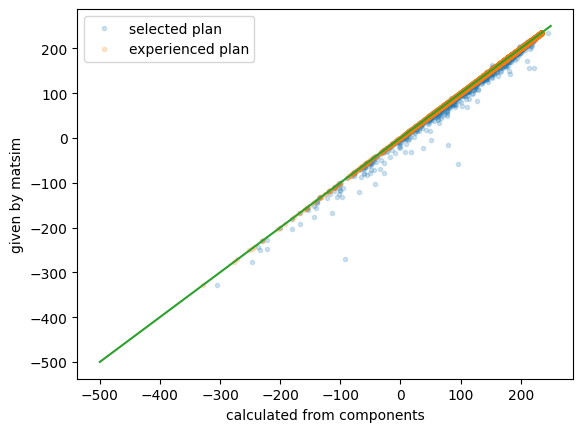

In [61]:
plt.plot(df["sp_calculated_total_u"], df["selected plan utility"], ".", alpha=0.2) #planned: calculated versus MATSIM (experirenced)
plt.plot(df["ep_calculated_total_u"], df["experienced plan utility"], ".", alpha=0.2) #experienced: calculated versus MATSIM (experirenced) - this should line up
lista = [-500, 50, 250]
plt.xlabel("calculated from components")
plt.ylabel("given by matsim")
plt.legend(["selected plan", "experienced plan"])
plt.plot(lista, lista)

Save utility breakdowns file here if wanted

In [62]:
def summariseAdjacentLegs(trips):
    final_new_trips = []
    # print(trips)
    for sublist_i in trips: 
        sub_new_trips = []
        for sublist_j in sublist_i:
            temp = [
                item for i, item in enumerate(sublist_j) 
                if i == 0 or item != sublist_j[i - 1]
            ]
            # print(temp)
            sub_new_trips.append(temp)
        final_new_trips.append(sub_new_trips)
    return(final_new_trips)

In [63]:
#turn the first modes and first durations, and overall utilities into their own columns
def get_safe_index(data, idx):
    if not isinstance(data, list):
        print("only one activity - bad agent")
        print(data["id"])
        return None
    # Use a list comprehension to handle the nested structure
    return [
        inner[idx] if isinstance(inner, list) and len(inner) > idx else None 
        for inner in data
    ]

In [64]:
#so this function just looks at the highest scoring unique modes, agnostic of which the selected plan is
#but i think we need something to be an anchor since this whole thing is relative and comparative
def trips_to_keep(modes, travel_u, activity_u):
    if not modes:
        return [], [], []
    if not (len(modes) == len(travel_u) == len(activity_u)):
        raise ValueError("All three lists must have the same length")
    if not len(modes)>1:
        raise ValueError("Need at least 2 activities and 1 mode: sruck agent or bad plan")
    # handle single-element case
    if len(modes) == 1:
        return (
            [tuple(modes[0]) if isinstance(modes[0], list) else modes[0]],
            [travel_u[0]],
            [activity_u[0]]
        )

    modes_fixed = [tuple(m) if isinstance(m, list) else m for m in modes]
    first_key = modes_fixed[0]
    # best per key -> (value, index)
    best = {}

    # scan items after index 0
    for idx in range(1, len(modes_fixed)):
        k = modes_fixed[idx]
        if k == first_key:
            continue
        v = travel_u[idx]
        if k not in best or v > best[k][0] or (v == best[k][0] and idx < best[k][1]):
            best[k] = (v, idx)

    # preserve order by the chosen item index (stable order)
    chosen_indices = [best[k][1] for k in sorted(best, key=lambda kk: best[kk][1])]

    # build output lists: prepend index 0
    modes_fixed   = [modes_fixed[0]] + [modes_fixed[i] for i in chosen_indices]
    travel_u_fixed = [travel_u[0]] + [travel_u[i] for i in chosen_indices]
    activity_u_fixed = [activity_u[0]] + [activity_u[i] for i in chosen_indices]

    return modes_fixed, travel_u_fixed, activity_u_fixed


In [65]:
import math
import scipy.stats as sp


def calculate_flex_score_power2(modes, travel_u, activity_u):
    components = [0,0,0,0] #maxium of 5 different modes giving 4 different flexes (can vary) 
    k = 2.944
    beta = 0.037
    
    modes, travel_u, activity_u = trips_to_keep(modes, travel_u, activity_u)
    for i in range(1, len(modes)):
        try:
            activity_u_ratio = (activity_u[0]-activity_u[i])/activity_u[0]
        except ZeroDivisionError:
            activity_u_ratio = 0
        # print(f"activity u ratio: {activity_u_ratio}")
        try:
            travel_u_ratio = (travel_u[0]-travel_u[i])/travel_u[0]
        except ZeroDivisionError:
            travel_u_ratio = 0
        # print(f"travel u ratio: {travel_u_ratio}")
        if travel_u_ratio * activity_u_ratio >= 0:
            sigma = -1
        else:
            sigma = 1
        # print(f"sigma: {sigma}")
        temp = (2/(1+np.exp(k*abs(travel_u_ratio)*np.exp(sigma*beta*abs(activity_u_ratio))))) 
        # print(f"temp: {temp}")
        components[i-1]= (temp)
    return(sp.pmean(components, 2))

In [66]:
df_flex = df

In [67]:
#collect the trips into lists
df_flex["sp_trips_groups"] = df_flex.apply(lambda row: moa.group_legs_into_trips(row["selected plan activity_type_or_mode"], row["sp_activities_indices"], row["sp_stuck_index"]), axis=1)
df_flex["up1_trips_groups"] = df_flex.apply(lambda row: moa.group_legs_into_trips(row["unselected plan (1) activity_type_or_mode"], row["up1_activities_indices"], row["up1_stuck_index"]), axis=1)
df_flex["up2_trips_groups"] = df_flex.apply(lambda row: moa.group_legs_into_trips(row["unselected plan (2) activity_type_or_mode"], row["up2_activities_indices"], row["up2_stuck_index"]), axis=1)
df_flex["up3_trips_groups"] = df_flex.apply(lambda row: moa.group_legs_into_trips(row["unselected plan (3) activity_type_or_mode"], row["up3_activities_indices"], row["up3_stuck_index"]), axis=1)
df_flex["up4_trips_groups"] = df_flex.apply(lambda row: moa.group_legs_into_trips(row["unselected plan (4) activity_type_or_mode"], row["up4_activities_indices"], row["up4_stuck_index"]), axis=1)

C:\Users\maria\AppData\Local\Temp\ipykernel_58812\486610768.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_flex["sp_trips_groups"] = df_flex.apply(lambda row: moa.group_legs_into_trips(row["selected plan activity_type_or_mode"], row["sp_activities_indices"], row["sp_stuck_index"]), axis=1)
C:\Users\maria\AppData\Local\Temp\ipykernel_58812\486610768.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_flex["up1_trips_groups"] = df_flex.apply(lambda row: moa.group_legs_into_trips(row["unselected plan (1) activity_type_or

In [68]:
df_flex["trips_modes"] = [[list(pair) for pair in zip(a, b,c,d,e)] for a, b ,c,d,e in zip(df_flex['sp_trips_groups'], df_flex['up1_trips_groups'],df_flex['up2_trips_groups'],df_flex['up3_trips_groups'],df_flex['up4_trips_groups'])]
df_flex["travel_utilities"] = [[list(pair) for pair in zip(a, b,c,d,e)] for a, b ,c,d,e in zip(df_flex['sp_calculated_travel_u'], df_flex['up1_calculated_travel_u'],df_flex['up2_calculated_travel_u'],df_flex['up3_calculated_travel_u'],df_flex['up4_calculated_travel_u'])]
df_flex["activity_utilities"] = [[list(pair) for pair in zip(a, b,c,d,e)] for a, b, c,d,e in zip(df_flex['sp_calculated_activity_u'], df_flex['up1_calculated_activity_u'], df_flex['up2_calculated_activity_u'],df_flex['up3_calculated_activity_u'],df_flex['up4_calculated_activity_u'])]

C:\Users\maria\AppData\Local\Temp\ipykernel_58812\1065230464.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_flex["trips_modes"] = [[list(pair) for pair in zip(a, b,c,d,e)] for a, b ,c,d,e in zip(df_flex['sp_trips_groups'], df_flex['up1_trips_groups'],df_flex['up2_trips_groups'],df_flex['up3_trips_groups'],df_flex['up4_trips_groups'])]
C:\Users\maria\AppData\Local\Temp\ipykernel_58812\1065230464.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_flex["travel_utilities"] = [[list(pair) for pair in zip(a, b,c,d,e)] for 

In [69]:
#collapse trips e.g, from walk, walk, bus to walk, bus
df_flex["trips_modes_summarised"] = df_flex["trips_modes"].apply(summariseAdjacentLegs)

C:\Users\maria\AppData\Local\Temp\ipykernel_58812\3438952575.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_flex["trips_modes_summarised"] = df_flex["trips_modes"].apply(summariseAdjacentLegs)


In [70]:
def calculate_flex_score_full_power2(day_modes, day_travel_u, day_activity_u):
    flex_store = []

    for i in range(len(day_modes)): 
        mode_temp = day_modes[i]
        travel_u_temp = day_travel_u[i]
        activity_u_temp = day_activity_u[i]
        flex_store.append(calculate_flex_score_power2(mode_temp, travel_u_temp, activity_u_temp))
    return np.mean(flex_store)


In [72]:
df_flex["f_score_full_power2"] = df_flex.apply(lambda row: calculate_flex_score_full_power2(row["trips_modes_summarised"], row["travel_utilities"], row["activity_utilities"]), axis=1)

C:\Users\maria\AppData\Local\Temp\ipykernel_58812\1824661189.py:18: RuntimeWarning: divide by zero encountered in scalar divide
  travel_u_ratio = (travel_u[0]-travel_u[i])/travel_u[0]
C:\Users\maria\AppData\Local\Temp\ipykernel_58812\1824661189.py:22: RuntimeWarning: invalid value encountered in scalar multiply
  if travel_u_ratio * activity_u_ratio >= 0:
C:\Users\maria\AppData\Local\Temp\ipykernel_58812\1902054461.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_flex["f_score_full_power2"] = df_flex.apply(lambda row: calculate_flex_score_full_power2(row["trips_modes_summarised"], row["travel_utilities"], row["activity_utilities"]), axis=1)


Text(0.5, 1.0, 'Histogram of population-wide flexibility scores')

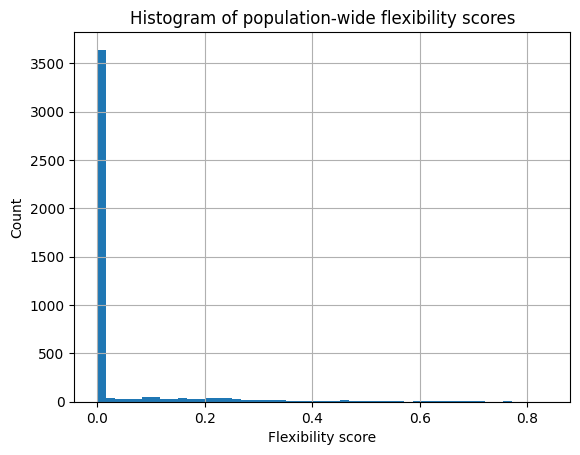

In [73]:
plt.hist(df_flex["f_score_full_power2"], bins=50)
plt.grid()
plt.xlabel("Flexibility score")
plt.ylabel("Count")
plt.title("Histogram of population-wide flexibility scores")